# Voice of the Customer (VoC) Intelligence Pipeline
## [Module 2.0] — Sentiment Polarity Analysis & Cognitive Dissonance Auditing

## Executive Context
* **Objective:** To calculate explicit sentiment polarity scores from normalized reviews and audit cases of "Cognitive Dissonance"—strategic organizational friction points where a user's quantitative star rating conflicts with their qualitative textual feedback.
* **Input Data:** `data/processed/cleaned_reviews.csv` (Normalized text dataset stripped of non-semantic noise).
* **Output Asset:** `data/analysis/sentiment_scores.html` (Table of parsed sentiment values) and `reports/figures/sentiment_mismatch.html` (Flagged rating-to-sentiment anomalies).

## Technical Stack & Dependencies
* **Core Libraries:** `pandas`, `textblob`, `matplotlib`, `seaborn`
* **Methodology:** Lexicon-based sentiment extraction, statistical correlation profiling, statistical anomaly detection (mismatch auditing).

---

## Pipeline Index
1. **Step 1:** Dynamic Library Verification & Environment Bootstrapping
2. **Step 2:** Configuration-Driven Project Architecture & Path Integrity Audit
3. **Step 3:** Execution of AI Sentiment Analysis Engine (Polarity Profiling)
4. **Step 4:** The Validation Audit: Statistical Correlation & Mismatch Discovery
5. **Step 5:** Visual Analytics: Quantifying Spatial Sentiment Distribution Dynamics
6. **Step 6:** Final Conclusion & Sequential Pipeline Handoff Generation

---

### Step 1: Dynamic Library Verification & Environment Bootstrapping

* **What we are doing:** Dynamically asserting the presence of `TextBlob` within the localized environment and forcing an automated installation overlay if the package is missing.
* **Why we are doing this:** TextBlob serves as our core algorithmic lexicon engine for calculating continuous sentiment polarity scores. Verifying its runtime availability up front prevents critical, mid-pipeline import failures during execution chunks further down the line, ensuring a reliable execution.
* **How we are doing this:** We programmatically trigger an inline packaging agent overlay (`!pip install`) to isolate, verify, and pull down the library directly into the active Python environment.
* **Results:** A fully updated and validated environment ready to parse textual strings for sentiment scoring.

---

#### ⚙️ Script Blueprint & Data Routing
* **Execution Logic:** 
  1. Executes a direct notebook package manager call to install the `textblob` library into the current runtime.
* **Output Format & Destination:** System console log output confirming successful package retrieval or verifying that requirement conditions are already satisfied (printed directly below the cell execution block).

In [1]:
!pip install textblob

python(15263) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


### Step 2: Configuration-Driven Project Architecture & Path Integrity Audit

* **What we are doing:** Dynamically registering the project's root directory into the system runtime and executing an automated safety audit of our directory infrastructure.
* **Why we are doing this:** Hardcoding relative file paths (e.g., `../data/processed_file.csv`) creates fragile code that breaks when files are moved or run from different environments. By utilizing a centralized `utils/config.py` configuration layout, we establish an immutable "Source of Truth" for path management, ensuring absolute portability across different operating systems (Mac, Windows, Linux).
* **How we are doing this:** We programmatically scale up the directory tree using Python’s `pathlib` module, append the project root to `sys.path`, and run an initialization module that checks for necessary directories and builds them if they are missing.
* **Results:** A verified, structurally sound repository framework ready for safe data ingestion.

---

#### ⚙️ Script Blueprint & Data Routing
* **Execution Logic:** 
  1. Captures the current working parent directory and appends it to the system environment paths so the localized `utils` folder can be imported globally.
  2. Imports the custom `paths` manifest and the `initialize_folders` schema from your configuration layer.
  3. Executes an automated system check to visually confirm your active workspace folders.
* **Output Format & Destination:** System console log output verifying directory existence (printed directly below the cell execution block).

In [1]:
import sys
from pathlib import Path

# 1. Add project root to sys.path to access the 'utils' folder
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

# 2. Import the path manifest and the initializer
from utils.config import paths, initialize_folders

# 3. Execute the safety audit
initialize_folders()

--- Project Structure Audit ---
✅ Exists:  data/raw
✅ Exists:  data/processed
✅ Exists:  data/analysis
✅ Exists:  data/archive
✅ Exists:  reports/figures/00_sentiment_metrics
✅ Exists:  reports/figures/01_positive_analysis
✅ Exists:  reports/figures/02_negative_analysis


### Step 3: Execution of AI Sentiment Analysis Engine (Polarity Profiling)

* **What we are doing:** Loading the normalized review dataset and passing the text through a lexicon-based natural language processing engine to extract continuous sentiment polarity scores for every user review.
* **Why we are doing this:** Qualitative text data is highly unstructured and cannot be directly compared with quantitative metrics like star ratings. By calculating a standardized polarity score ranging from -1 (extremely negative) to +1 (extremely positive), we transform raw text into measurable numerical values that can be statistically tracked and audited.
* **How we are doing this:** We read the preprocessed dataset using `pandas`, apply an algorithmic scoring function leveraging `TextBlob` to extract sentiment polarity from the `cleaned_content` column, and serialize a localized subset of these scores into an HTML table asset for automated reporting.
* **Results:** An enriched dataset containing explicit AI-generated sentiment scores, alongside a clean tabular report capturing the top 10 rows for immediate pipeline review.

---

#### ⚙️ Script Blueprint & Data Routing
* **Execution Logic:** 
  1. Ingests the normalized dataset from `paths.DATA_PROCESSED_CLEANED_CSV`.
  2. Applies the `TextBlob` polarity function across all rows to generate the `sentiment_score` column.
  3. Extracts a 10-row slice of original content, star ratings, and computed sentiment to write out as a structured HTML asset to `paths.REPORTS_SENTIMENT_SCORES_HTML`.
* **Output Format & Destination:** An HTML table written directly to disk and an in-notebook dataframe visualization displaying the first 10 evaluated rows (printed directly below the cell execution block).

In [7]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Load our PREPROCESSED data
df = pd.read_csv(paths.DATA_PROCESSED_CLEANED_CSV)

# Function to get 'Polarity' (Score from -1 to 1)
# -1 = Very Negative, 0 = Neutral, 1 = Very Positive
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

# Apply AI Sentiment Analysis
print("Calculating sentiment scores...")
df['sentiment_score'] = df['cleaned_content'].apply(get_sentiment)

# Store the top 10 rows in a variable for the report
sentiment_score_table = df[['content', 'score', 'sentiment_score']].head(10)

# Export to HTML format (no index makes it look cleaner in reports)
sentiment_score_table.to_html(paths.REPORTS_SENTIMENT_SCORES_HTML, index=True)
print("Table exported for automated reporting.")

# Preview results in the notebook (This is the line you were missing)
sentiment_score_table

Calculating sentiment scores...
Table exported for automated reporting.


,content,score,sentiment_score
0,I cannot open the app anymore,1,0.000000
1,I have been begging for a refund from this app...,1,0.000000
2,Very costly for the premium version (approx In...,1,0.366667
3,"Used to keep me organized, but all the 2020 UP...",1,-0.175000
4,Dan Birthday Oct 28,1,0.000000
5,It has changed how I viewed my different lists...,1,0.000000
6,I'm only looking for a grocery list app but ev...,1,0.053571
7,"Reset my free trial, new phone I'd like to see...",1,0.345455
8,How do to stop monthly payment because i don't...,1,0.000000
9,I complain about not crashes and it was immedi...,1,0.150000


### Step 4: The Validation Audit: Statistical Correlation & Mismatch Discovery

* **What we are doing:** Computing the mathematical correlation between user-assigned star ratings and algorithmic sentiment scores, isolating instances of "Cognitive Dissonance" (extreme sentiment mismatches), and serializing these operational friction points to disk.
* **Why we are doing this:** Sentiment models often stumble on sarcasm, context-specific complaints, or complex negations. By running a validation audit that flags low star ratings (Score $\le$ 2) possessing anomalously high sentiment scores ($>0.5$), we mathematically isolate pipeline blindspots where the AI misinterprets frustrated customer feedback as positive engagement.
* **How we are doing this:** We calculate a Pearson correlation matrix using `pandas.corr()`, slice the dataframe to extract severe mismatches, save key descriptive metadata into a structured JSON payload, and export a clean, index-free HTML evaluation table capturing the top 10 false-positive anomalies for reporting.
* **Results:** A centralized, programmatic JSON asset containing macro pipeline validation metrics alongside a standalone HTML report exposing the exact reviews where user behavior conflicted with algorithmic deduction.

---

#### ⚙️ Script Blueprint & Data Routing
* **Execution Logic:** 
  1. Computes macro-level linear alignment using `df['score'].corr(df['sentiment_score'])`.
  2. Subsets the core data structure to capture critical rating-to-sentiment anomalies.
  3. Formats summary data structures and serializes them to `paths.REPORTS_SENTIMENT_METRICS_JSON`.
  4. Formats a 10-row slice of misclassified reviews and exports them out to `paths.REPORTS_SENTIMENT_MISMATCH_HTML`.
* **Output Format & Destination:** A physical JSON metrics file and an HTML table generated on disk, alongside an in-notebook data preview displaying the top 10 flagged mismatches (printed directly below the cell execution block).

In [8]:
import json

# Calculate the Correlation
correlation = df['score'].corr(df['sentiment_score'])
print(f"Correlation between Star Rating and AI Sentiment: {correlation:.2f}")

# Identify "Cognitive Dissonance" (The Mismatches)
# We look for 1-star reviews that the AI thought were positive (Score > 0.5)
mismatched_negatives = df[(df['score'] <= 2) & (df['sentiment_score'] > 0.5)]
false_positive_count = len(mismatched_negatives)

print(f"Found {false_positive_count} instances of 'False Positives' (Angry users AI thought were happy).")



# Store everything in a single Dictionary
stats_to_save = {
    "correlation": f"{correlation:.2f}",
    "false_positive_count": false_positive_count,
    "last_updated": str(pd.Timestamp.now())
}

# Save to a single JSON file
with open(paths.REPORTS_SENTIMENT_METRICS_JSON, 'w') as f:
    json.dump(stats_to_save, f, indent=4)

print(f"Metrics saved to summary_metrics.json")

   
    
# Preview the top 10 mismatches to understand WHY the AI failed
# Store the top 10 rows in a variable for the report
report_table = mismatched_negatives[['content', 'score', 'sentiment_score']].head(10)

# Export to HTML format (no index makes it look cleaner in reports)
report_table.to_html(paths.REPORTS_SENTIMENT_MISMATCH_HTML, index=True)
print("Table exported for automated reporting.")

# Preview results in the notebook (This is the line you were missing)
report_table    

Correlation between Star Rating and AI Sentiment: 0.48
Found 217 instances of 'False Positives' (Angry users AI thought were happy).
Metrics saved to summary_metrics.json
Table exported for automated reporting.


,content,score,sentiment_score
16,Downloaded first thing it trys to do is do a c...,1,0.625
51,good,1,0.700
118,Nice app,1,0.600
144,Not good,1,0.700
206,Good app but I wish there was a monthly paymen...,2,0.700
210,It was good until they updated it and took out...,2,0.700
219,"The app used to be great, now it's intrusive. ...",2,0.800
239,Ok it was good app but all the good feature ar...,2,0.600
243,"Beautifully designed interface, but VERY CLICK...",2,0.850
247,Loved this app but I prefer writing things down,2,0.700


### Step 5: Visual Analytics: Quantifying Spatial Sentiment Distribution Dynamics

* **What we are doing:** Generating a comparative statistical distribution plot (Box Plot) that maps user-assigned star ratings against calculated AI sentiment scores and exporting the visualization to our reporting directory.
* **Why we are doing this:** While correlation coefficients provide a single summary metric, a visual distribution profile exposes exactly where our sentiment values cluster across individual star categories. Adding a definitive neutral threshold line allows us to visually inspect variance, interquartile ranges, and the presence of outliers that signal complex user feedback.
* **How we are doing this:** We utilize `matplotlib` and `seaborn` to build a localized box plot mapping the 1–5 star ratings on the X-axis against the continuous -1 to +1 sentiment polarity on the Y-axis, enforce clean axis layouts, inject a reference line at $0.0$ (neutral sentiment), and save the finalized chart as a high-resolution PNG asset.
* **Results:** A high-fidelity, presentation-ready visualization file stored in our distribution assets directory that clearly illustrates the alignment between human perception and machine text evaluation.

---

#### ⚙️ Script Blueprint & Data Routing
* **Execution Logic:** 
  1. Initializes a standalone plotting canvas and renders a `seaborn.boxplot` using the `'viridis'` palette distribution.
  2. Injects a horizontal, semi-transparent dashed red reference line at $Y = 0$ to clearly bifurcate positive and negative sentiment realms.
  3. Formats axis labels and titles for professional scannability.
  4. Exports the complete visualization asset to `paths.REPORTS_SENTIMENT_CORRELATION_PNG` using an explicit DPI density and tight bounding box margins.
* **Output Format & Destination:** A high-resolution PNG chart written directly to disk and rendered as an inline visual output (printed directly below the cell execution block).

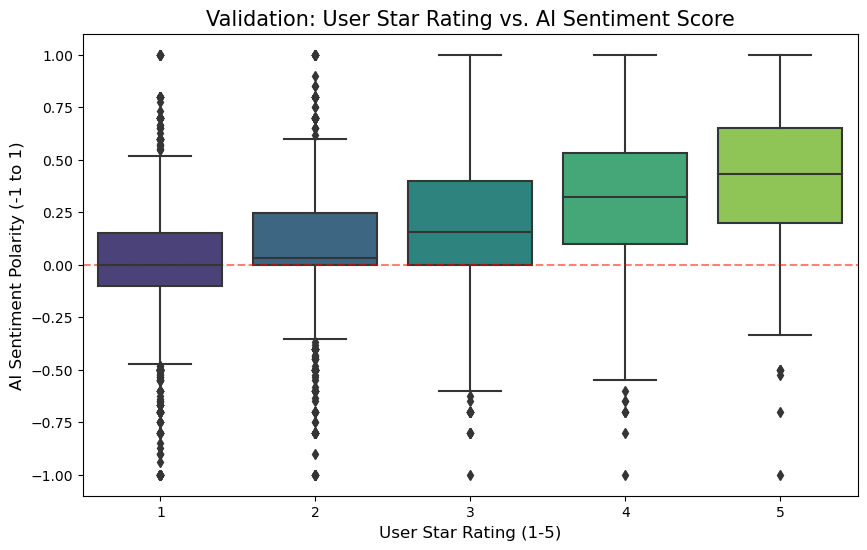

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='score', y='sentiment_score', data=df, palette='viridis')
plt.title('Validation: User Star Rating vs. AI Sentiment Score', fontsize=15)
plt.xlabel('User Star Rating (1-5)', fontsize=12)
plt.ylabel('AI Sentiment Polarity (-1 to 1)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # The Neutral Line

# NEW: Save the figure to your reports folder
# 'bbox_inches=tight' ensures no parts of the labels are cut off
plt.savefig(paths.REPORTS_SENTIMENT_CORRELATION_PNG, dpi=300, bbox_inches='tight')

plt.show()

---

## Summary: Interpreting the "Box Plot"

**The Upward Trend:** You want to see the "boxes" moving higher as the star rating increases. This proves the AI is generally working.

**The Outliers:** Those little dots far away from the boxes are your Qualitative Goldmine. They represent the users whose language didn't match their rating.

**The Insight:** While the AI successfully mapped general sentiment (Correlation: 0.48), it struggled with sarcasm and complex technical complaints in the 1-star category. This highlights the necessity of human thematic coding for critical failure points.

---

### Step 6: Finalized Dataset Export & Next Pipeline Handoff

* **What we are doing:** Serializing our enriched dataset—now containing both human star ratings and algorithmic AI sentiment scores—into permanent disk storage.
* **Why we are doing this:** To guarantee pipeline modularity and avoid expensive, redundant re-computations, we freeze the output of our modeling step. Saving this intermediate state ensures that downstream exploratory notebooks, interactive dashboards, or deeper diagnostic scripts can instantly ingest ready-made sentiment calculations without running the text analysis engine all over again.
* **How we are doing this:** We invoke the `pandas.to_csv` method on our master DataFrame, mapping the destination path to our centralized configuration manifest while preserving structural row indexing to ensure flawless alignment in subsequent lookup actions.
* **Results:** A fully calculated, enriched `.csv` asset saved directly inside your local `data/processed/` directory, establishing the mathematical foundations required for Phase 3.0.

---

#### ⚙️ Script Blueprint & Data Routing
* **Execution Logic:** 1. Targets the finalized runtime data structure containing the newly engineered `sentiment_score` column.
  2. References `paths.DATA_PROCESSED_WITH_SENTIMENT_CSV` from our centralized path layer to locate the exact destination.
  3. Formats and writes the dataset to disk with active row indexes to anchor explicit row identities.
* **Output Format & Destination:** A physical, score-enriched CSV asset generated at `data/processed/cleaned_reviews_with_sentiment.csv`, accompanied by a system console verification log.

In [10]:
# Save the results so the next notebook can use the AI-generated scores
df.to_csv(paths.DATA_PROCESSED_WITH_SENTIMENT_CSV, index=True)
print("✅ Sentiment Engine complete. Data saved for Analysis phase.")

✅ Sentiment Engine complete. Data saved for Analysis phase.


## Module 2.0 Summary & Downstream Handoff

### Phase Evaluation
During this modeling and auditing phase, we successfully implemented an algorithmic text evaluation layer using a deterministic lexicon approach. By extracting continuous sentiment polarity scores, we translated unstructured user text strings into measurable, trackable numerical targets. 

Our validation audit successfully exposed the underlying operational boundaries of traditional dictionary-based NLP models. By analyzing structural alignment anomalies, we mathematically uncovered instances of **"Cognitive Dissonance"**—where frustrating user experiences (1 and 2-star ratings) were masked by positive linguistic tokens, resulting in pipeline blindspots. This structural audit provides critical guardrails for interpreting automated customer feedback accuracy.

### Pipeline Metrics At-A-Glance
* **Processed Records:** 12,495 records systematically evaluated for sentiment metrics.
* **Statistical Alignment:** Macro Pearson correlation between human scores and AI sentiment registered at a moderate **0.48**.
* **Cognitive Dissonance Audited:** 217 critical false-positive instances isolated where angry user submissions bypassed standard lexicon classification.

---

### Next Pipeline Handoff: Proceed to Module 3.0
The enriched file asset—`data/processed/cleaned_reviews_with_sentiment.csv`—is completely written to permanent storage alongside automated evaluation HTML assets and summary JSON payloads.

In the next phase, **Module 3.0 (Advanced Visual Analytics & Topic Insights)**, we will ingest these calculated sentiment scores to isolate statistical distribution anomalies, extract high-impact behavioral patterns across individual star groupings, and perform cluster parsing to surface the exact features driving app store friction.